In [7]:
# Load the trained Wrc
import torch
import numpy as np
from matplotlib import pyplot as plt
model_dict = torch.load(f'../time_exp/2TS_1_rnn.pth', map_location=torch.device('cuda'))

# Get the weights and biases
Wrc = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()
print('Wrc shape:', Wrc.shape)  # (N,N)

# Load Wrc_theory
Wrc_theory = np.load('Wrc_theory.npy')

# Load Wrc_space
model_dict = torch.load(f'../space_exp/square_room_rnn.pth', map_location=torch.device('cuda'))
Wrc_space = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()

Wrc shape: (512, 512)


### Sort Wrc and plug it back to the RNN

The observation is, after sorting (put most of positive entries to upper right), the time cell doesn't show up.

In [3]:
# Calculate the ratio of positive entries to total entries
import numpy as np
num_positive = np.sum(Wrc > 0)
num_negative = np.sum(Wrc < 0)
total_entries = 512 * 512
ratio_positive = num_positive / total_entries
ratio_negative = num_negative / total_entries
print(f'Ratio of positive entries to total entries: {ratio_positive:.4f}')
print(f'Ratio of negative entries to total entries: {ratio_negative:.4f}')

Ratio of positive entries to total entries: 0.3613
Ratio of negative entries to total entries: 0.6387


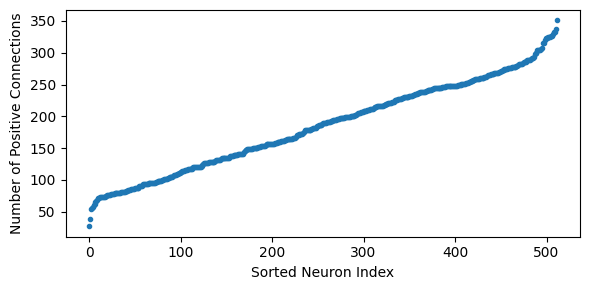

In [47]:
# Get the number of positive entries in each row
positive_counts_per_row = np.sum(Wrc > 0, axis=1)
sorted_counts = np.sort(positive_counts_per_row)
# Plot positive counts vs neuron index
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(sorted_counts, marker='o', linestyle='None', markersize=3)
plt.xlabel('Sorted Neuron Index')
plt.ylabel('Number of Positive Connections')    
plt.tight_layout()
plt.show()

In [3]:
# Extract the diagonal elements
diags = np.diag(Wrc)
# Check if all diags are negative
num_neg = np.sum(diags < 0)
print(f'Number of negative diagonal elements: {num_neg} out of {len(diags)}')

Number of negative diagonal elements: 441 out of 512


In [ ]:
def positives_mask(W, pos_threshold=0.0):
    return (W > pos_threshold).astype(float)

def ur_objective(A, rperm, cperm):
    """
    Reward positives that are higher rows (smaller row index) and farther-right columns (larger col index).
    Equivalent to: sum_{i,j} A[i,j] * ( (nr-1 - rrank[i]) + crank[j] )
    """
    nr, nc = A.shape
    rrank = np.empty(nr, dtype=int)
    rrank[rperm] = np.arange(nr)                # row rank after perm
    crank = np.empty(nc, dtype=int)
    crank[cperm] = np.arange(nc)                # col rank after perm

    # weights: higher is better for objective
    row_w = (nr - 1) - rrank                    # top rows have larger weight
    col_w = crank                               # right columns have larger weight

    # sum A[i,j]*(row_w[i] + col_w[j])
    # compute efficiently via matrix ops
    return (A * (row_w[:, None] + col_w[None, :])).sum()

def sort_rows_given_cols(A, cperm):
    """
    Score each row by how far-right its positives lie, given a column order.
    Put rows with larger weighted positives earlier (top).
    """
    nr, nc = A.shape
    col_rank = np.empty(nc, dtype=int)
    col_rank[cperm] = np.arange(nc)             # 0..nc-1 (right is larger)
    # row score = sum_j A[i,j] * col_rank[j]
    scores = A @ col_rank.astype(float)
    rperm = np.argsort(-scores)                 # larger score -> earlier (top)
    return rperm

def sort_cols_given_rows(A, rperm):
    """
    Score each column by how high the positives sit, given a row order.
    Put columns with larger weighted positives later (right).
    """
    nr, nc = A.shape
    row_rank = np.empty(nr, dtype=int)
    row_rank[rperm] = np.arange(nr)             # 0..nr-1 (top is smaller)
    # we want columns with positives higher up to get larger reward,
    # so use row_weight = (nr-1 - row_rank) so top rows contribute more.
    row_w = (nr - 1) - row_rank
    # col score = sum_i A[i,j] * row_w[i]
    scores = row_w.astype(float) @ A
    cperm = np.argsort(scores)                  # smaller -> left, larger -> right
    return cperm

def greedy_adjacent_refine_rows(A, rperm, cperm, max_passes=3):
    best = rperm.copy()
    best_obj = ur_objective(A, best, cperm)
    nr = A.shape[0]
    for _ in range(max_passes):
        improved = False
        for i in range(nr-1):
            cand = best.copy()
            cand[i], cand[i+1] = cand[i+1], cand[i]
            obj = ur_objective(A, cand, cperm)
            if obj > best_obj:
                best, best_obj, improved = cand, obj, True
        if not improved:
            break
    return best

def greedy_adjacent_refine_cols(A, rperm, cperm, max_passes=3):
    best = cperm.copy()
    best_obj = ur_objective(A, rperm, best)
    nc = A.shape[1]
    for _ in range(max_passes):
        improved = False
        for j in range(nc-1):
            cand = best.copy()
            cand[j], cand[j+1] = cand[j+1], cand[j]
            obj = ur_objective(A, rperm, cand)
            if obj > best_obj:
                best, best_obj, improved = cand, obj, True
        if not improved:
            break
    return best

def sort_matrix_push_ur_bi(W, pos_threshold=0.0, alt_passes=5, refine_passes=3,
                           init="counts"):
    """
    Decoupled row/col ordering to push positives to the upper-right.
    Returns: row_perm, col_perm, W_sorted
    - alt_passes: alternating passes of row/column sorts
    - refine_passes: greedy adjacent swap refinement for rows and columns
    - init: "counts" | "random"
    """
    A = positives_mask(W, pos_threshold)

    nr, nc = A.shape
    if init == "random":
        rperm = np.random.permutation(nr)
        cperm = np.random.permutation(nc)
    else:
        # sensible init: rows with more positives on top; columns with more positives on the right
        row_counts = A.sum(axis=1)
        col_counts = A.sum(axis=0)
        rperm = np.argsort(-row_counts)         # more positives -> higher
        cperm = np.argsort(col_counts)          # fewer positives -> left

    # alternating optimization
    for _ in range(alt_passes):
        rperm = sort_rows_given_cols(A, cperm)
        cperm = sort_cols_given_rows(A, rperm)

    # optional greedy local refinement
    if refine_passes and refine_passes > 0:
        rperm = greedy_adjacent_refine_rows(A, rperm, cperm, max_passes=refine_passes)
        cperm = greedy_adjacent_refine_cols(A, rperm, cperm, max_passes=refine_passes)

    W_sorted = W[rperm][:, cperm]
    return rperm, cperm, W_sorted

In [5]:
rperm, cperm, W_ur = sort_matrix_push_ur_bi(Wrc, pos_threshold=0.0,
                                            alt_passes=5, refine_passes=3)

In [ ]:
def _pos_mass(A):
    return np.sum(np.maximum(A, 0.0))

def _safe_norm_div(a, b):
    return a / (b + 1e-12)

def eval_sort_metrics_bi(W, rperm=None, cperm=None, perm=None, n_rand=50, seed=0):
    """
    Evaluate how well (rperm, cperm) push positives toward the upper-right (UR).
    If 'perm' is provided (and rperm/cperm are None), falls back to single-permutation
    triangle-style metrics for backward compatibility.

    Returns a dict of metrics, baseline means/stds, and z-scores.
    """
    rng = np.random.default_rng(seed)
    P = np.maximum(W, 0.0)
    total_pos = _pos_mass(W) + 1e-12

    nr, nc = W.shape

    # --------- Backward-compatible path (single perm) ----------
    if perm is not None and (rperm is None and cperm is None):
        n = W.shape[0]
        Wp = W[perm][:, perm]
        Pp = np.maximum(Wp, 0.0)

        iu = np.triu_indices(n, k=1)
        il = np.tril_indices(n, k=-1)

        S_mass = Pp[iu].sum() / total_pos
        S_count = (Wp[iu] > 0).sum() / max((Wp > 0).sum(), 1)

        r = np.empty(n, dtype=int)
        r[perm] = np.arange(n)
        pos_mask = (W > 0)
        i_idx, j_idx = np.where(pos_mask)
        ok = (r[i_idx] < r[j_idx])
        weights = W[pos_mask]
        S_cons = (weights * ok).sum() / (weights.sum() + 1e-12)

        P_lower = Pp[il].sum() / total_pos
        dist = (iu[1] - iu[0])
        S_UR = (Pp[iu] * dist).sum() / ((n - 1) * total_pos)

        metrics = dict(
            mode="single_perm",
            S_mass=float(S_mass),
            S_count=float(S_count),
            S_cons=float(S_cons),
            P_lower=float(P_lower),
            S_UR=float(S_UR),
        )

        if n_rand > 0:
            rand_metrics = []
            for _ in range(n_rand):
                pr = rng.permutation(n)
                Wr = W[pr][:, pr]
                Pr = np.maximum(Wr, 0.0)
                Smr = Pr[iu].sum() / total_pos
                Scr = (Wr[iu] > 0).sum() / max((Wr > 0).sum(), 1)

                rr = np.empty(n, dtype=int); rr[pr] = np.arange(n)
                okr = (rr[i_idx] < rr[j_idx])
                Sconr = (weights * okr).sum() / (weights.sum() + 1e-12)

                Plr = Pr[il].sum() / total_pos
                S_URr = (Pr[iu] * dist).sum() / ((n - 1) * total_pos)

                rand_metrics.append([Smr, Scr, Sconr, Plr, S_URr])

            rand_metrics = np.array(rand_metrics)
            mean = rand_metrics.mean(axis=0)
            std  = rand_metrics.std(axis=0) + 1e-12
            z = (np.array([S_mass, S_count, S_cons, P_lower, S_UR]) - mean) / std
            metrics.update({
                "z_S_mass": float(z[0]),
                "z_S_count": float(z[1]),
                "z_S_cons": float(z[2]),
                "z_P_lower": float(z[3]),  # more negative is better here
                "z_S_UR": float(z[4]),
                "baseline_mean": {
                    "S_mass": float(mean[0]),
                    "S_count": float(mean[1]),
                    "S_cons": float(mean[2]),
                    "P_lower": float(mean[3]),
                    "S_UR": float(mean[4]),
                },
                "baseline_std": {
                    "S_mass": float(std[0]),
                    "S_count": float(std[1]),
                    "S_cons": float(std[2]),
                    "P_lower": float(std[3]),
                    "S_UR": float(std[4]),
                }
            })
        return metrics

    # --------- Bi-permutation path (independent row/col orderings) ----------
    assert rperm is not None and cperm is not None, \
        "Provide either (perm) or (rperm and cperm)."

    # ranks after applying permutations
    rrank = np.empty(nr, dtype=int); rrank[rperm] = np.arange(nr)
    crank = np.empty(nc, dtype=int); crank[cperm] = np.arange(nc)

    # Row/Col weights to encode UR preference:
    # - rows: higher rows (smaller rank) should have larger weight
    # - cols: farther-right columns (larger rank) should have larger weight
    if nr > 1:
        row_w = (nr - 1 - rrank) / (nr - 1)  # in [0,1], top rows ~1
    else:
        row_w = np.zeros(nr)
    if nc > 1:
        col_w = (crank) / (nc - 1)           # in [0,1], rightmost ~1
    else:
        col_w = np.zeros(nc)

    # Core UR scores (two flavors; pick what you like to report)
    # Additive: reward = row_weight + col_weight (normalize by 2 for [0,1])
    S_UR_add = _safe_norm_div((P * (row_w[:, None] + col_w[None, :])).sum(), 2 * total_pos)
    # Multiplicative: reward = row_weight * col_weight  (strict UR emphasis)
    S_UR_mul = _safe_norm_div((P * (row_w[:, None] * col_w[None, :])).sum(), total_pos)

    # Constraint satisfaction: for each positive W[i,j], prefer row_rank[i] < col_rank[j]
    pos_mask = (W > 0)
    i_idx, j_idx = np.where(pos_mask)
    ok = (rrank[i_idx] < crank[j_idx]).astype(float)
    weights = W[pos_mask]
    S_cons = _safe_norm_div((weights * ok).sum(), weights.sum())

    # Optional: “top mass” and “right mass” (marginals)
    top_mass   = _safe_norm_div((P[rrank <= (nr-1)//2]).sum(), total_pos) if nr > 1 else 0.0
    right_mass = _safe_norm_div((P[:, crank >= (nc-1)//2]).sum(), total_pos) if nc > 1 else 0.0

    metrics = dict(
        mode="bi_perm",
        S_UR_add=float(S_UR_add),   # in [0,1]
        S_UR_mul=float(S_UR_mul),   # in [0,1], stricter toward UR corner
        S_cons=float(S_cons),       # in [0,1]
        top_mass=float(top_mass),
        right_mass=float(right_mass),
    )

    # Baseline via random independent permutations
    if n_rand > 0:
        rand_vals = []
        for _ in range(n_rand):
            rp = rng.permutation(nr)
            cp = rng.permutation(nc)
            rr = np.empty(nr, dtype=int); rr[rp] = np.arange(nr)
            cr = np.empty(nc, dtype=int); cr[cp] = np.arange(nc)

            if nr > 1:
                rw = (nr - 1 - rr) / (nr - 1)
            else:
                rw = np.zeros(nr)
            if nc > 1:
                cw = (cr) / (nc - 1)
            else:
                cw = np.zeros(nc)

            S_add = _safe_norm_div((P * (rw[:, None] + cw[None, :])).sum(), 2 * total_pos)
            S_mul = _safe_norm_div((P * (rw[:, None] * cw[None, :])).sum(), total_pos)

            okr = (rr[i_idx] < cr[j_idx]).astype(float)
            Scon = _safe_norm_div((weights * okr).sum(), weights.sum())

            topm   = _safe_norm_div((P[rr <= (nr-1)//2]).sum(), total_pos) if nr > 1 else 0.0
            rightm = _safe_norm_div((P[:, cr >= (nc-1)//2]).sum(), total_pos) if nc > 1 else 0.0

            rand_vals.append([S_add, S_mul, Scon, topm, rightm])

        rand_vals = np.array(rand_vals)
        mean = rand_vals.mean(axis=0)
        std  = rand_vals.std(axis=0) + 1e-12

        z = (np.array([S_UR_add, S_UR_mul, S_cons, top_mass, right_mass]) - mean) / std
        metrics.update({
            "z_S_UR_add": float(z[0]),
            "z_S_UR_mul": float(z[1]),
            "z_S_cons": float(z[2]),
            "z_top_mass": float(z[3]),
            "z_right_mass": float(z[4]),
            "baseline_mean": {
                "S_UR_add": float(mean[0]),
                "S_UR_mul": float(mean[1]),
                "S_cons": float(mean[2]),
                "top_mass": float(mean[3]),
                "right_mass": float(mean[4]),
            },
            "baseline_std": {
                "S_UR_add": float(std[0]),
                "S_UR_mul": float(std[1]),
                "S_cons": float(std[2]),
                "top_mass": float(std[3]),
                "right_mass": float(std[4]),
            }
        })

    return metrics


In [17]:
metric = eval_sort_metrics_bi(Wrc, rperm=rperm, cperm=cperm, n_rand=50, seed=0)

S_UR_add: 0.6161
S_UR_mul: 0.4132
S_cons: 0.7242
top_mass: 0.7521
right_mass: 0.5892
z_S_UR_add: 18.6604
z_S_UR_mul: 25.9212
z_S_cons: 18.2979
z_top_mass: 13.2241
z_right_mass: 8.7187


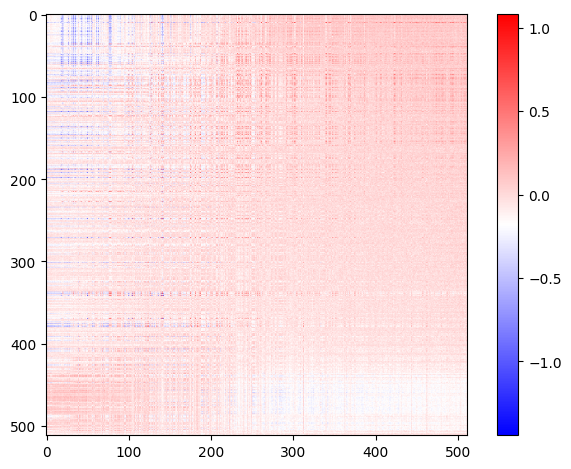

In [21]:
for key, value in metric.items():
    if key != 'mode' and key != 'baseline_mean' and key != 'baseline_std':
        print(f'{key}: {value:.4f}')
        
from matplotlib import pyplot as plt
plt.imshow(W_ur, cmap='bwr')
plt.colorbar()
plt.tight_layout()
plt.show()

In [26]:
def _neg_mass(A):
    return np.sum(np.maximum(-A, 0.0))

def _safe_div(a, b):
    return a / (b + 1e-12)

def eval_neg_lower_left_bi(W, rperm=None, cperm=None, perm=None, n_rand=50, seed=0):
    """
    Evaluate how well negatives are pushed to the lower-left (LL).
    - If perm is provided (single permutation, square), reproduce the strict lower-triangle metrics.
    - If (rperm, cperm) are provided, use bi-permutation metrics:
        * DL half-plane mask (rows in bottom half, cols in left half)
        * Additive & multiplicative LL scores with continuous weights:
              down_w = rrank/(nr-1)   (越靠下越大)
              left_w = (nc-1-crank)/(nc-1) (越靠左越大)
    Returns a dict with metrics and (optionally) z-scores vs random baselines.
    """
    rng = np.random.default_rng(seed)
    N = np.maximum(-W, 0.0)     # negative magnitude
    total_neg = _neg_mass(W) + 1e-12
    nr, nc = W.shape

    # -------- 单置换：严格下三角（与你现有定义一致） --------
    if perm is not None and (rperm is None and cperm is None):
        n = W.shape[0]
        assert n == W.shape[1], "single-permutation LL metrics assume square matrix"
        Wp = W[perm][:, perm]
        LL_rows, LL_cols = np.tril_indices(n, k=-1)
        LL = Wp[LL_rows, LL_cols]

        LL_size = len(LL)  # n*(n-1)/2
        neg_LL_count = np.sum(LL < 0)
        frac_neg_LL_count = _safe_div(neg_LL_count, LL_size)

        neg_LL_mass = np.sum(np.maximum(-LL, 0.0))
        frac_neg_mass_in_LL_of_total = _safe_div(neg_LL_mass, total_neg)
        avg_neg_mag_per_LL_cell = _safe_div(neg_LL_mass, LL_size)

        dist = (LL_rows - LL_cols)  # 1..(n-1)
        S_LL_neg_dist = _safe_div((np.maximum(-LL, 0.0) * dist).sum(), (n - 1) * total_neg)

        metrics = dict(
            mode="single_perm",
            frac_neg_LL_count=float(frac_neg_LL_count),
            frac_neg_mass_in_LL_of_total=float(frac_neg_mass_in_LL_of_total),
            avg_neg_mag_per_LL_cell=float(avg_neg_mag_per_LL_cell),
            S_LL_neg_dist=float(S_LL_neg_dist),
        )

        # baseline: random single permutations
        if n_rand > 0:
            rand_vals = []
            for _ in range(n_rand):
                pr = rng.permutation(n)
                Wr = W[pr][:, pr]
                LLr = Wr[np.tril_indices(n, k=-1)]
                size = len(LLr)
                neg_cnt = np.sum(LLr < 0)
                frac_cnt = _safe_div(neg_cnt, size)

                neg_mass = np.sum(np.maximum(-LLr, 0.0))
                frac_mass = _safe_div(neg_mass, total_neg)
                avg_mag = _safe_div(neg_mass, size)

                rr, cc = np.tril_indices(n, k=-1)
                dist = (rr - cc)
                Sdist = _safe_div((np.maximum(-LLr, 0.0) * dist).sum(), (n - 1) * total_neg)

                rand_vals.append([frac_cnt, frac_mass, avg_mag, Sdist])
            rand_vals = np.array(rand_vals)
            mean = rand_vals.mean(axis=0); std = rand_vals.std(axis=0) + 1e-12
            cur = np.array([metrics["frac_neg_LL_count"],
                            metrics["frac_neg_mass_in_LL_of_total"],
                            metrics["avg_neg_mag_per_LL_cell"],
                            metrics["S_LL_neg_dist"]])
            z = (cur - mean) / std
            metrics.update({
                "z_frac_neg_LL_count": float(z[0]),
                "z_frac_neg_mass_in_LL_of_total": float(z[1]),
                "z_avg_neg_mag_per_LL_cell": float(z[2]),
                "z_S_LL_neg_dist": float(z[3]),
                "baseline_mean": {
                    "frac_neg_LL_count": float(mean[0]),
                    "frac_neg_mass_in_LL_of_total": float(mean[1]),
                    "avg_neg_mag_per_LL_cell": float(mean[2]),
                    "S_LL_neg_dist": float(mean[3]),
                },
                "baseline_std": {
                    "frac_neg_LL_count": float(std[0]),
                    "frac_neg_mass_in_LL_of_total": float(std[1]),
                    "avg_neg_mag_per_LL_cell": float(std[2]),
                    "S_LL_neg_dist": float(std[3]),
                }
            })
        return metrics

    # -------- 双置换：下×左与连续权重 --------
    assert rperm is not None and cperm is not None, "Provide either perm or (rperm, cperm)."

    # ranks after permutations
    rrank = np.empty(nr, dtype=int); rrank[rperm] = np.arange(nr)
    crank = np.empty(nc, dtype=int); crank[cperm] = np.arange(nc)

    # 连续权重：越靠下越大、越靠左越大；标准化到 [0,1]
    if nr > 1:
        down_w = rrank / (nr - 1)
    else:
        down_w = np.zeros(nr)
    if nc > 1:
        left_w = (nc - 1 - crank) / (nc - 1)
    else:
        left_w = np.zeros(nc)

    # 1) 连续 LL 得分（越大说明负值更集中在左下）
    S_LL_add = _safe_div((N * (down_w[:, None] + left_w[None, :])).sum(), 2 * total_neg)
    S_LL_mul = _safe_div((N * (down_w[:, None] * left_w[None, :])).sum(), total_neg)

    # 2) 半平面掩码：bottom-half × left-half
    bottom_mask = rrank >= (nr // 2) if nr > 1 else np.ones(nr, dtype=bool)
    left_mask   = crank <= (nc - 1) // 2 if nc > 1 else np.ones(nc, dtype=bool)
    DL_mask = np.outer(bottom_mask, left_mask)

    DL_size = int(bottom_mask.sum() * left_mask.sum())
    neg_DL_mass = (N * DL_mask).sum()
    neg_DL_count = (W[DL_mask] < 0).sum()

    frac_neg_DL_count = _safe_div(neg_DL_count, DL_size)
    frac_neg_mass_in_DL_of_total = _safe_div(neg_DL_mass, total_neg)
    avg_neg_mag_per_DL_cell = _safe_div(neg_DL_mass, DL_size)

    # 3) 距离型（可选）：用“行向下距离 × 列向左距离”的期望值（效果类似乘性）
    if nr > 1 and nc > 1:
        row_dist = rrank / (nr - 1)                    # 0..1（越下越大）
        col_dist = (nc - 1 - crank) / (nc - 1)         # 0..1（越左越大）
        S_LL_neg_dist = _safe_div((N * (row_dist[:, None] * col_dist[None, :])).sum(), total_neg)
    else:
        S_LL_neg_dist = 0.0

    metrics = dict(
        mode="bi_perm",
        # 连续权重分数
        S_LL_add=float(S_LL_add),
        S_LL_mul=float(S_LL_mul),
        S_LL_neg_dist=float(S_LL_neg_dist),
        # 半平面掩码分数
        frac_neg_DL_count=float(frac_neg_DL_count),
        frac_neg_mass_in_DL_of_total=float(frac_neg_mass_in_DL_of_total),
        avg_neg_mag_per_DL_cell=float(avg_neg_mag_per_DL_cell),
    )

    # 基线：随机独立行/列置换
    if n_rand > 0:
        rand_vals = []
        for _ in range(n_rand):
            rp = rng.permutation(nr)
            cp = rng.permutation(nc)
            rr = np.empty(nr, dtype=int); rr[rp] = np.arange(nr)
            cr = np.empty(nc, dtype=int); cr[cp] = np.arange(nc)

            if nr > 1:
                dw = rr / (nr - 1)
            else:
                dw = np.zeros(nr)
            if nc > 1:
                lw = (nc - 1 - cr) / (nc - 1)
            else:
                lw = np.zeros(nc)

            Sadd = _safe_div((N * (dw[:, None] + lw[None, :])).sum(), 2 * total_neg)
            Smul = _safe_div((N * (dw[:, None] * lw[None, :])).sum(), total_neg)

            if nr > 1 and nc > 1:
                row_dist = rr / (nr - 1)
                col_dist = (nc - 1 - cr) / (nc - 1)
                Sdist = _safe_div((N * (row_dist[:, None] * col_dist[None, :])).sum(), total_neg)
            else:
                Sdist = 0.0

            bmask = rr >= (nr // 2) if nr > 1 else np.ones(nr, dtype=bool)
            lmask = cr <= (nc - 1) // 2 if nc > 1 else np.ones(nc, dtype=bool)
            DLm = np.outer(bmask, lmask)
            DLs = int(bmask.sum() * lmask.sum())
            neg_mass = (N * DLm).sum()
            neg_cnt = (W[DLm] < 0).sum()

            frac_cnt = _safe_div(neg_cnt, DLs)
            frac_mass = _safe_div(neg_mass, total_neg)
            avg_mag = _safe_div(neg_mass, DLs)

            rand_vals.append([Sadd, Smul, Sdist, frac_cnt, frac_mass, avg_mag])

        rand_vals = np.array(rand_vals)
        mean = rand_vals.mean(axis=0); std = rand_vals.std(axis=0) + 1e-12
        cur = np.array([metrics["S_LL_add"], metrics["S_LL_mul"], metrics["S_LL_neg_dist"],
                        metrics["frac_neg_DL_count"], metrics["frac_neg_mass_in_DL_of_total"],
                        metrics["avg_neg_mag_per_DL_cell"]])
        z = (cur - mean) / std

        metrics.update({
            "z_S_LL_add": float(z[0]),
            "z_S_LL_mul": float(z[1]),
            "z_S_LL_neg_dist": float(z[2]),
            "z_frac_neg_DL_count": float(z[3]),
            "z_frac_neg_mass_in_DL_of_total": float(z[4]),
            "z_avg_neg_mag_per_DL_cell": float(z[5]),
            "baseline_mean": {
                "S_LL_add": float(mean[0]),
                "S_LL_mul": float(mean[1]),
                "S_LL_neg_dist": float(mean[2]),
                "frac_neg_DL_count": float(mean[3]),
                "frac_neg_mass_in_DL_of_total": float(mean[4]),
                "avg_neg_mag_per_DL_cell": float(mean[5]),
            },
            "baseline_std": {
                "S_LL_add": float(std[0]),
                "S_LL_mul": float(std[1]),
                "S_LL_neg_dist": float(std[2]),
                "frac_neg_DL_count": float(std[3]),
                "frac_neg_mass_in_DL_of_total": float(std[4]),
                "avg_neg_mag_per_DL_cell": float(std[5]),
            }
        })

    return metrics


In [25]:
neg_LL_metrics = eval_neg_lower_left_bi(Wrc, rperm, cperm)

In [28]:
for key, value in neg_LL_metrics.items():
    if key != 'mode' and key != 'baseline_mean' and key != 'baseline_std':
        print(f'{key}: {value:.4f}')

S_LL_add: 0.5789
S_LL_mul: 0.2872
S_LL_neg_dist: 0.2872
frac_neg_DL_count: 0.7174
frac_neg_mass_in_DL_of_total: 0.2694
avg_neg_mag_per_DL_cell: 0.0704
z_S_LL_add: 15.6883
z_S_LL_mul: 7.3903
z_S_LL_neg_dist: 7.3903
z_frac_neg_DL_count: 10.0857
z_frac_neg_mass_in_DL_of_total: 2.4764
z_avg_neg_mag_per_DL_cell: 2.4764


In [29]:
#Save W_ur
np.save('Wrc_ur.npy', W_ur)

### Compare spectrum between Wrc and Wtheory

In [31]:
def spectral_similarity(A, B, k=None):
    eigA = np.linalg.eigvals(A)
    eigB = np.linalg.eigvals(B)
    # sort by real part for comparison
    eigA = np.sort_complex(eigA)
    eigB = np.sort_complex(eigB)
    dist = np.linalg.norm(np.sort(eigA) - np.sort(eigB)) / np.linalg.norm(eigA)
    return {'Eigen_distance': dist}

W_thory = np.load('Wrc_theory.npy')
spec_sim = spectral_similarity(Wrc, W_thory)
print(spec_sim)

{'Eigen_distance': np.float64(4.601980983856341)}


In [32]:
def baseline_eigen_distance(A, n_samples=100):
    eigA = np.linalg.eigvals(A)
    norms = []
    for _ in range(n_samples):
        B = np.random.permutation(A.flatten()).reshape(A.shape)
        eigB = np.linalg.eigvals(B)
        dist = np.linalg.norm(np.sort_complex(eigA) - np.sort_complex(eigB)) / np.linalg.norm(eigA)
        norms.append(dist)
    return np.mean(norms), np.std(norms)
mean_dist, std_dist = baseline_eigen_distance(Wrc, n_samples=100)
print(f'Baseline eigen distance: mean={mean_dist:.4f}, std={std_dist:.4f}')

Baseline eigen distance: mean=1.1003, std=0.0151


### Figure out Wrc structure

Firstly, it's not symmetric. Make Wrc symmetric doesn't give time cells.

In [3]:
asymmetry_ratio = np.linalg.norm(Wrc - Wrc.T, 'fro') / (np.linalg.norm(Wrc, 'fro'))
print("Asymmetry ratio =", asymmetry_ratio)

Asymmetry ratio = 1.5608238


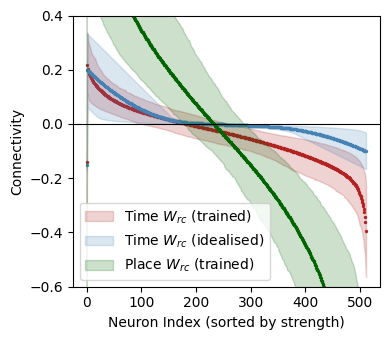

In [9]:
def sortW(W):
    # Iterate over rows of Wrc
    Wrc_sorted = np.zeros_like(W)
    for irow, row in enumerate(W):
        # Except itself, sort the indices of the other neurons by weight
        row_values = np.zeros_like(row)
        row_values[0] = row[irow]  # keep self-connection
        # Get the indices of other neurons sorted by weight
        other_indices = np.argsort(row)
        sorted_indices = [i for i in other_indices if i != irow]
        sorted_indices = sorted_indices[::-1]  # descending order
        # Fill in the row_values with sorted weights
        for j, idx in enumerate(sorted_indices):
            row_values[j + 1] = row[idx]
        Wrc_sorted[irow] = row_values
        
    mean_sorted = np.mean(Wrc_sorted, axis=0)
    percentile_16 = np.percentile(Wrc_sorted, 16, axis=0)
    percentile_84 = np.percentile(Wrc_sorted, 84, axis=0)
    return mean_sorted, percentile_16, percentile_84

mean_sorted, percentile_16, percentile_84 = sortW(Wrc)
mean_theory, p16_theory, p84_theory = sortW(Wrc_theory)
mean_space, p16_space, p84_space = sortW(Wrc_space)

# Plot the sorted Wrc
plt.figure(figsize=(4,3.5))
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.fill_between(range(len(mean_sorted)), percentile_16, percentile_84, alpha=0.2,
                 color='firebrick', label=r'Time $W_{rc}$ (trained)')
plt.scatter(range(len(mean_sorted)), mean_sorted, color='firebrick', s=2)
plt.fill_between(range(len(mean_theory)), p16_theory, p84_theory, alpha=0.2,
                 color='steelblue', label=r'Time $W_{rc}$ (idealised)')
plt.scatter(range(len(mean_theory)), mean_theory, color='steelblue', s=2)
plt.fill_between(range(len(mean_space)), p16_space, p84_space, alpha=0.2,
                 color='darkgreen', label=r'Place $W_{rc}$ (trained)')
plt.scatter(range(len(mean_space)), mean_space, color='darkgreen', s=2)
# plt.title('Wrc with Sorted Rows')
plt.legend(loc='lower left')
plt.xlabel('Neuron Index (sorted by strength)')
plt.ylabel('Connectivity')
# plt.yscale('symlog')
plt.ylim(-0.6, 0.4)
plt.tight_layout()
plt.savefig('Connection_vs_distance.png', transparent=True, dpi=500)

This means neuron strongly inhibits itself and exhibits weakly global inhibition. 

In [ ]:
def check_locality(W):
    n = W.shape[0]
    dist = np.abs(np.arange(n)[:,None] - np.arange(n)[None,:]) # (512, 512)
    dist = np.minimum(dist, n - dist)  # circular distance

    # Get the mean
    mean_weight_by_dist = [np.mean(W[dist == d]) for d in range(n//2)]
    # Get the 16th and 84th percentiles
    percentile_16 = [np.percentile(W[dist == d], 16) for d in range(n//2)]
    percentile_84 = [np.percentile(W[dist == d], 100) for d in range(n//2)]
    percentile_50 = [np.percentile(W[dist == d], 50) for d in range(n//2)]
    # Plot mean with shaded percentiles
    plt.figure(figsize=(5,4))
    plt.fill_between(range(n//2), percentile_16, percentile_84, alpha=0.3,
                     color='steelblue',label='16th-84th percentile')
    plt.plot(percentile_50, color='steelblue', linestyle='--', label='Median')
    plt.plot(mean_weight_by_dist, color='firebrick', label='Mean')
    # plt.title("Mean connection vs distance (circular)")
    plt.xlabel("Distance (index difference)")
    plt.ylabel("Weight")
    plt.legend()
    plt.tight_layout()  
    
check_locality(Wrc)
plt.savefig('Connection_vs_distance.png', transparent=True, dpi=500)

In [ ]:
S = 0.5*(Wrc + Wrc.T)
K = 0.5*(Wrc - Wrc.T)
direction_ratio = np.linalg.norm(K, 'fro') / (np.linalg.norm(Wrc, 'fro'))
symmetric_ratio = np.linalg.norm(S, 'fro') / (np.linalg.norm(Wrc, 'fro'))
print("Symmetric ratio:", symmetric_ratio**2)
print("Directionality ratio:", direction_ratio**2, 1-symmetric_ratio**2)

mean_upper= -0.02029507  mean_lower= -0.01977573
max Re(λ) = 5.3360896
spectral radius = 28.139124


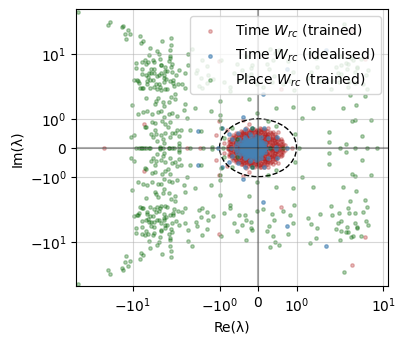

In [11]:
eig = np.linalg.eigvals(Wrc)
eig_space = np.linalg.eigvals(Wrc_space)
eig_theory = np.linalg.eigvals(Wrc_theory)
plt.figure(figsize=(4,3.5))
plt.scatter(eig.real, eig.imag, s=6, c='firebrick', alpha=0.3, label=r'Time $W_{rc}$ (trained)')
# Plot a circle of radius 1
circle = plt.Circle((0, 0), 1.0, color='black', alpha=1, linestyle='--', fill=False)
plt.gca().add_artist(circle)
plt.scatter(eig_theory.real, eig_theory.imag, s=6, c='steelblue', alpha=0.6, label=r'Time $W_{rc}$ (idealised)')
plt.scatter(eig_space.real, eig_space.imag, s=6, c='darkgreen', alpha=0.3, label=r'Place $W_{rc}$ (trained)')
plt.axhline(0,c='k', alpha=0.3); plt.axvline(0,c='k', alpha=0.3)
plt.xlabel('Re(λ)'); plt.ylabel('Im(λ)')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.xscale('symlog')
plt.yscale('symlog')
plt.savefig('eigen_spectrum.png', transparent=True, dpi=500)
# plt.title('Eigen spectrum')
upper = np.triu(Wrc, 1); lower = np.tril(Wrc, -1)
print('mean_upper=', np.nanmean(upper), ' mean_lower=', np.nanmean(lower))
print("max Re(λ) =", np.max(eig.real))
print("spectral radius =", np.max(np.abs(eig)))

### PCA

Simulate how a higher dimensional representation vector $x\in\mathbb{R}^{512}$ changes with time under the matrix $W_{rc}$. Given the dynamics:

\begin{equation}\dot{x}=W_{rc}x\end{equation}

Because the trajectory in 2D space is spiral and decaying, the excitation between neurons propagates and returns to itself, e.g., A --> B --> C --> D --> A. The connectivity in this direction is positive. We call this a "local loop".

The decay means the circumference of the local loop is decreasing. 

/home/shannon/miniconda3/envs/STCell/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:773: RuntimeWarning: overflow encountered in square
  self.explained_variance_ = (S**2) / (n_samples - 1)
/home/shannon/miniconda3/envs/STCell/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:784: RuntimeWarning: overflow encountered in square
  X_centered **= 2
/home/shannon/miniconda3/envs/STCell/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:787: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
/home/shannon/miniconda3/envs/STCell/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:791: RuntimeWarning: invalid value encountered in scalar subtract
  self.noise_variance_ = total_var - xp.sum(self.explained_variance_)


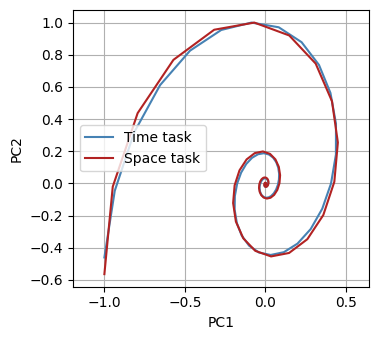

In [118]:
def simulate_linear(W, x0=None, dt=0.01, T=10):
    N = W.shape[0]
    if x0 is None:
        x0 = np.random.randn(N)
    t = np.arange(0, T, dt)
    X = np.zeros((len(t), N))
    X[0] = x0
    for i in range(1, len(t)):
        X[i] = X[i-1] + dt * (W @ X[i-1])
    return t, X

# simulate and project to top 2 PCA
from sklearn.decomposition import PCA

# np.random.seed(50)

x0 = np.random.randn(Wrc.shape[0])
t, X = simulate_linear(Wrc, x0=x0,T=10)
t, X_space = simulate_linear(Wrc_space, x0=x0, T=10)
t, X_theory = simulate_linear(Wrc_theory, x0=x0, T=10)

pca = PCA(n_components=2)
proj = pca.fit_transform(X)
pca = PCA(n_components=2)
proj_space = pca.fit_transform(X_space)
pca = PCA(n_components=2)
proj_theory = pca.fit_transform(X_theory)

plt.figure(figsize=(4, 3.5))
# Rescale for better visualization
proj[:,0] /= np.max(np.abs(proj[:,0]))
proj[:,1] /= np.max(np.abs(proj[:,1]))
proj_space[:,0] /= np.max(np.abs(proj_space[:,0]))
proj_space[:,1] /= np.max(np.abs(proj_space[:,1]))
proj_theory[:,0] /= np.max(np.abs(proj_theory[:,0]))
proj_theory[:,1] /= np.max(np.abs(proj_theory[:,1]))
plt.plot(proj[:,0], proj[:,1], color='steelblue', label='Time task')
plt.plot(proj_space[:,0], proj_space[:,1], color='firebrick', label='Space task')
# plt.plot(proj_theory[:,0], proj_theory[:,1], color='green', label='Wrc theory')
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.axis('equal')
plt.grid(True)
plt.savefig('Trajectory_2D_PCA.png', transparent=True, dpi=500)

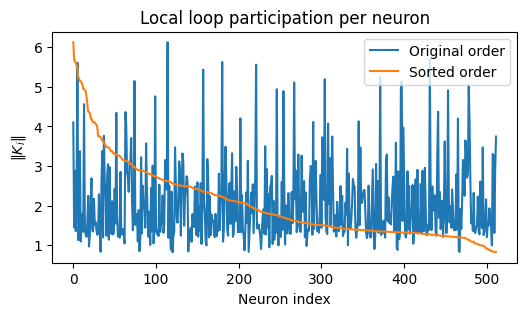

In [107]:
K = 0.5 * (Wrc - Wrc.T)
flow_strength = np.linalg.norm(K, axis=1)  # 每个神经元的环路参与强度
# Sort flow_strength from max to min
sort_idx = np.argsort(-flow_strength)
sort_strength = flow_strength[sort_idx]
plt.figure(figsize=(6,3))
plt.plot(flow_strength, label='Original order')
plt.plot(sort_strength, label='Sorted order')
plt.title("Local loop participation per neuron")
plt.xlabel("Neuron index"); plt.ylabel(r"‖$K_i$‖")
plt.legend()
plt.show()

### Is Wrc normal?

Is $W_{rc}^T W_{rc} = W_{rc} W_{rc}^T$?

In [69]:
# Check if Wrc is a normal matrix
W_WT = Wrc @ Wrc.T
WT_W = Wrc.T @ Wrc
normality_deviation = np.linalg.norm(W_WT - WT_W, 'fro') / np.linalg.norm(Wrc, 'fro')**2
print("Normality deviation =", normality_deviation)

Normality deviation = 0.41895738


### Schur denoise

In [ ]:
from numpy.linalg import norm
from scipy.linalg import schur

# ---------------------------
# 0) Utilities
# ---------------------------

def quality(W, Wh):
    fro_err  = norm(W - Wh, 'fro') / (norm(W, 'fro') + 1e-12)
    corr     = np.corrcoef(W.ravel(), Wh.ravel())[0, 1]
    return {
        'fro_err': fro_err,
        'corr': float(corr),
    }

# ---------------------------
# 1) Baseline: strong self-inhibit + uniform weak inhibit
#     W0 = -λ I + β * 1 1^T / (no scaling or 1/N — choose one consistently)
# ---------------------------
def baseline_W0(W, divide_by_N=False):
    N = W.shape[0]
    lam = -np.mean(np.diag(W))                         # >0, magnitude of self-inhibition
    off = W.copy(); np.fill_diagonal(off, np.nan)
    beta_elem_mean = np.nanmean(off)                   # mean of off-diagonal entries
    if divide_by_N:
        W0 = -lam*np.eye(N) + beta_elem_mean * np.ones((N, N)) / N
    else:
        # keep the same elementwise mean scale as your matrix statistics
        W0 = -lam*np.eye(N) + beta_elem_mean * np.ones((N, N))
    return W0, lam, beta_elem_mean

# ---------------------------
# 2) Schur-band denoising (preserves directionality)
#    Keep a few superdiagonals (forward flow) and very few subdiagonals (backflow).
# ---------------------------
def schur_band_denoise(W, sup_band=3, sub_band=1):
    # Real Schur: W = Q T Q^T, T quasi-upper-triangular (2x2 blocks for complex pairs)
    T, Q = schur(W, output='real')
    Th = T.copy()
    n = T.shape[0]
    for i in range(n):
        for j in range(n):
            if j > i and (j - i) > sup_band:
                Th[i, j] = 0.0
            if i > j and (i - j) > sub_band:
                Th[i, j] = 0.0
    return Q @ Th @ Q.T

# ---------------------------
# 4) One-stop wrappers you can call directly
# ---------------------------
def reconstruct_schur(W, sup_band=3, sub_band=1, subtract_W0=True, divide_by_N=False):
    """
    Option A: Schur-band denoise, optionally after removing W0.
    """
    if subtract_W0:
        W0, lam, beta = baseline_W0(W, divide_by_N=divide_by_N)
        R = W - W0
        Rhat = schur_band_denoise(R, sup_band=sup_band, sub_band=sub_band)
        Wh = W0 + Rhat
        meta = {'lam': lam, 'beta': beta, 'sup_band': sup_band, 'sub_band': sub_band}
    else:
        Wh = schur_band_denoise(W, sup_band=sup_band, sub_band=sub_band)
        meta = {'sup_band': sup_band, 'sub_band': sub_band}
    return Wh, meta

In [128]:
# ---------------------------
# 5) Demo / How to run (assumes your matrix is Wrc)
# ---------------------------
if __name__ == "__main__":
    
    # --- A) Schur-band denoise ---
    Wh_schur, meta_s = reconstruct_schur(Wrc, sup_band=3, sub_band=1, 
                                         subtract_W0=True, divide_by_N=False # Only use if do baseline_w0
                                         )
    print("SCHUR meta:", meta_s)
    print("SCHUR quality:", quality(Wrc, Wh_schur))
    
    np.save('Wrc_schur.npy', Wh_schur)

SCHUR meta: {'lam': np.float32(0.14008452), 'beta': np.float32(-0.04014922), 'sup_band': 3, 'sub_band': 1}
SCHUR quality: {'fro_err': np.float64(0.4927639250628029), 'corr': 0.8555741525965179}


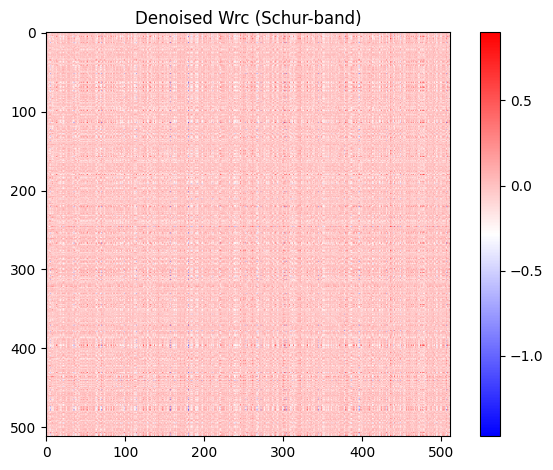

In [86]:
# Plot the denoised matrix
plt.imshow(Wh_schur, cmap='bwr')
plt.colorbar()
plt.title('Denoised Wrc (Schur-band)')
plt.tight_layout()
plt.show()

In [87]:
def denoise_report(W, What):
    R = W - What  # residual = removed part

    # Energy accounting
    fro_W = np.linalg.norm(W, 'fro')
    fro_R = np.linalg.norm(R, 'fro')
    energy_removed_share = (fro_R**2) / (fro_W**2 + 1e-24)
    energy_kept_share    = 1.0 - energy_removed_share

    # Similarity (flattened correlation)
    w = W.ravel(); wh = What.ravel()
    w = w - w.mean(); wh = wh - wh.mean()
    corr = (w @ wh) / (np.linalg.norm(w)*np.linalg.norm(wh) + 1e-24)

    # Operator 2-norm of residual (largest singular value)
    op_norm_resid = np.linalg.svd(R, compute_uv=False)[0]

    # Directionality (antisymmetric share) before/after
    def dir_share(A):
        K = 0.5*(A - A.T)
        return (np.linalg.norm(K,'fro')**2)/(np.linalg.norm(A,'fro')**2 + 1e-24)

    dir_before = dir_share(W)
    dir_after  = dir_share(What)

    # Non-normality before/after
    def nonnormality(A):
        return np.linalg.norm(A@A.T - A.T@A, 'fro') / (np.linalg.norm(A,'fro')**2 + 1e-24)

    nn_before = nonnormality(W)
    nn_after  = nonnormality(What)

    return {
        "energy_removed_share": float(energy_removed_share),
        "energy_kept_share": float(energy_kept_share),
        "corr_W_What": float(corr),
        "op_norm_residual": float(op_norm_resid),
        "directionality_share_before": float(dir_before),
        "directionality_share_after": float(dir_after),
        "nonnormality_before": float(nn_before),
        "nonnormality_after": float(nn_after),
    }

report = denoise_report(Wrc, Wh_schur)
for k,v in report.items(): print(f"{k:>28}: {v:.6f}")

        energy_removed_share: 0.189109
           energy_kept_share: 0.810891
                 corr_W_What: 0.890317
            op_norm_residual: 16.195700
 directionality_share_before: 0.609043
  directionality_share_after: 0.634473
         nonnormality_before: 0.418957
          nonnormality_after: 0.434952


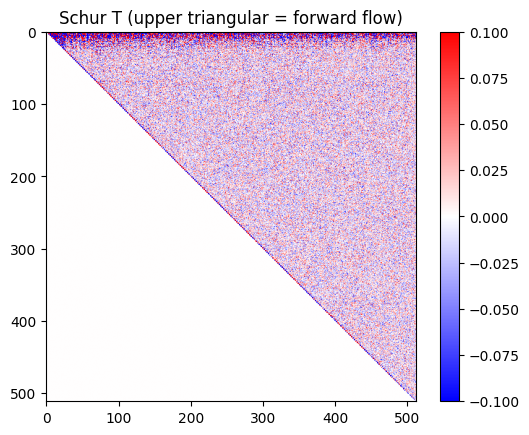

In [88]:
from scipy.linalg import schur
T, Q = schur(Wrc, output='real')
plt.imshow(T, cmap='bwr', vmin=-0.1, vmax=0.1)
plt.title("Schur T (upper triangular = forward flow)")
plt.colorbar()
plt.show()